In [1]:
from src.utils import * 
import pandas as pd
import numpy as np

base_dir = get_dir_name(True)
try:
    os.mkdir(base_dir + "/feature_set")
except FileExistsError:
    pass
sym = -1
# together_csv(base_dir + "/train_set", base_dir + f"/feature_set/no_feature_sym{sym}.csv", sym)
df = pd.read_csv(base_dir + f"/feature_set/no_feature_sym{sym}.csv")

In [2]:
df['time_period'] = df['time'].apply(lambda x: 'AM' if x < '11:20:00' else 'PM')
# 根据时段分别处理数据
am_df = df[df['time_period'] == 'AM']
pm_df = df[df['time_period'] == 'PM']

In [3]:
bid_cols = ['n_bid1', 'n_bid2', 'n_bid3', 'n_bid4', 'n_bid5']
ask_cols = ['n_ask1', 'n_ask2', 'n_ask3', 'n_ask4', 'n_ask5']
bsize_cols = ['n_bsize1', 'n_bsize2', 'n_bsize3', 'n_bsize4', 'n_bsize5']
asize_cols = ['n_asize1', 'n_asize2', 'n_asize3', 'n_asize4', 'n_asize5']

In [4]:
bid_values = df[bid_cols].values
ask_values = df[ask_cols].values
bsize_values = df[bsize_cols].values
asize_values = df[asize_cols].values

In [5]:
spread = ask_values - bid_values
for i in range(5):
    df[f'spread{i + 1}'] = spread[:, i]
spread_cols = [f'spread{i + 1}' for i in range(5)]

In [6]:
t = pd.to_datetime(df['time'], format='%H:%M:%S')
hours = t.dt.hour
minutes = t.dt.minute
seconds = t.dt.second
df['time_frac'] = (hours * 3600 + minutes * 60 + seconds) / 86400.0

In [7]:
df['amount']=np.log1p(df['amount_delta'])
df['is_amount_0'] = (df['amount'] == 0).astype(int)
df['abnormal'] = (df[spread_cols] < 0).any(axis=1).astype(int)

In [8]:
pd.set_option('display.max_columns', None)

In [9]:
df[bsize_cols].describe()

,n_bsize1,n_bsize2,n_bsize3,n_bsize4,n_bsize5
count,2.038980e+06,2.038980e+06,2.038980e+06,2.038980e+06,2.038980e+06
mean,1.874777e-01,7.496852e-02,7.917792e-02,8.229890e-02,8.278654e-02
std,3.021022e+00,1.987243e-01,1.943319e-01,2.069338e-01,2.082883e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.595889e-03,6.790523e-03,8.063746e-03,8.073193e-03,8.073193e-03
50%,1.614639e-02,2.489285e-02,2.816686e-02,2.844897e-02,2.825617e-02
75%,5.042669e-02,7.290048e-02,7.966570e-02,8.148627e-02,8.141289e-02
max,2.318488e+02,1.611578e+01,1.605078e+01,1.594028e+01,1.578861e+01


In [10]:
# 检测右偏程度
from scipy.stats import skew
print(skew(df[bsize_cols]))  # >2 表示严重右偏

[37.53827215 12.30016966 11.87190013 11.85428657 11.68165611]


In [11]:
normal_df = df[df['abnormal'] == 0]
normal_df[bsize_cols].describe()

,n_bsize1,n_bsize2,n_bsize3,n_bsize4,n_bsize5
count,2.029588e+06,2.029588e+06,2.029588e+06,2.029588e+06,2.029588e+06
mean,5.345318e-02,7.278772e-02,7.888992e-02,8.238882e-02,8.303298e-02
std,1.566483e-01,1.846787e-01,1.919410e-01,2.061603e-01,2.086963e-01
min,1.201562e-06,1.050489e-05,1.231989e-05,1.231989e-05,1.050489e-05
25%,4.595889e-03,6.790523e-03,8.073193e-03,8.073193e-03,8.073193e-03
50%,1.614639e-02,2.489285e-02,2.810058e-02,2.839150e-02,2.833575e-02
75%,4.978569e-02,7.265873e-02,7.945602e-02,8.163888e-02,8.185935e-02
max,9.219586e+00,1.014007e+01,8.746528e+00,9.183256e+00,1.578861e+01


In [12]:
print(skew(normal_df[bsize_cols]))  # >2 表示严重右偏

[14.573066   12.20187067 11.09299773 11.29354682 11.66270588]


In [13]:
# 分sym编号看一下
for sym in range(5):
    sym_df = normal_df[normal_df['sym'] == sym]
    print(f"Sym: {sym}")
    print("Skewness:", skew(sym_df[bsize_cols]))
    print()

Sym: 0
Skewness: [11.47542421 10.33264625  9.63073386 10.49795984 10.19541556]

Sym: 1
Skewness: [22.99181498 27.76647797 30.72016346 33.55606145 31.0629712 ]

Sym: 2
Skewness: [9.0335454  7.05648544 8.27019582 9.21077194 9.41391396]

Sym: 3
Skewness: [12.0955894   9.29853801  8.82011724  9.14581314  8.9020468 ]

Sym: 4
Skewness: [11.1524004  11.38594401  9.99238988  9.69990476 11.85424074]



In [14]:
# 写一个函数
# 针对sym不同的股票画6个子图
# 关键字参数sym和cols和df
# 给定sym和cols和df画直方图
# 每个子图的x轴是cols的值，y轴是cols的计数
# 最后一个是所有cols的重叠
def plot_hist(sym, cols, df):

    # 设置画布大小
    plt.figure(figsize=(15, 10))
    sym_df = df[df['sym'] == sym]
    # 画6个子图
    for i, col in enumerate(cols):
        plt.subplot(2, 3, i + 1)
        sns.histplot(sym_df[col], bins=30, kde=True)
        plt.title(f'Sym {sym} - {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

    # # 最后一个是所有cols的重叠
    # plt.subplot(2, 3, len(cols) + 1)
    # for col in cols:
    #     sns.histplot(sym_df[col], bins=30, kde=True, label=col)
    # plt.title('All Symbols - Overlap')
    # plt.xlabel('Value')
    # plt.ylabel('Count')
    # plt.legend()

    # 显示图形
    plt.tight_layout()
    plt.show()



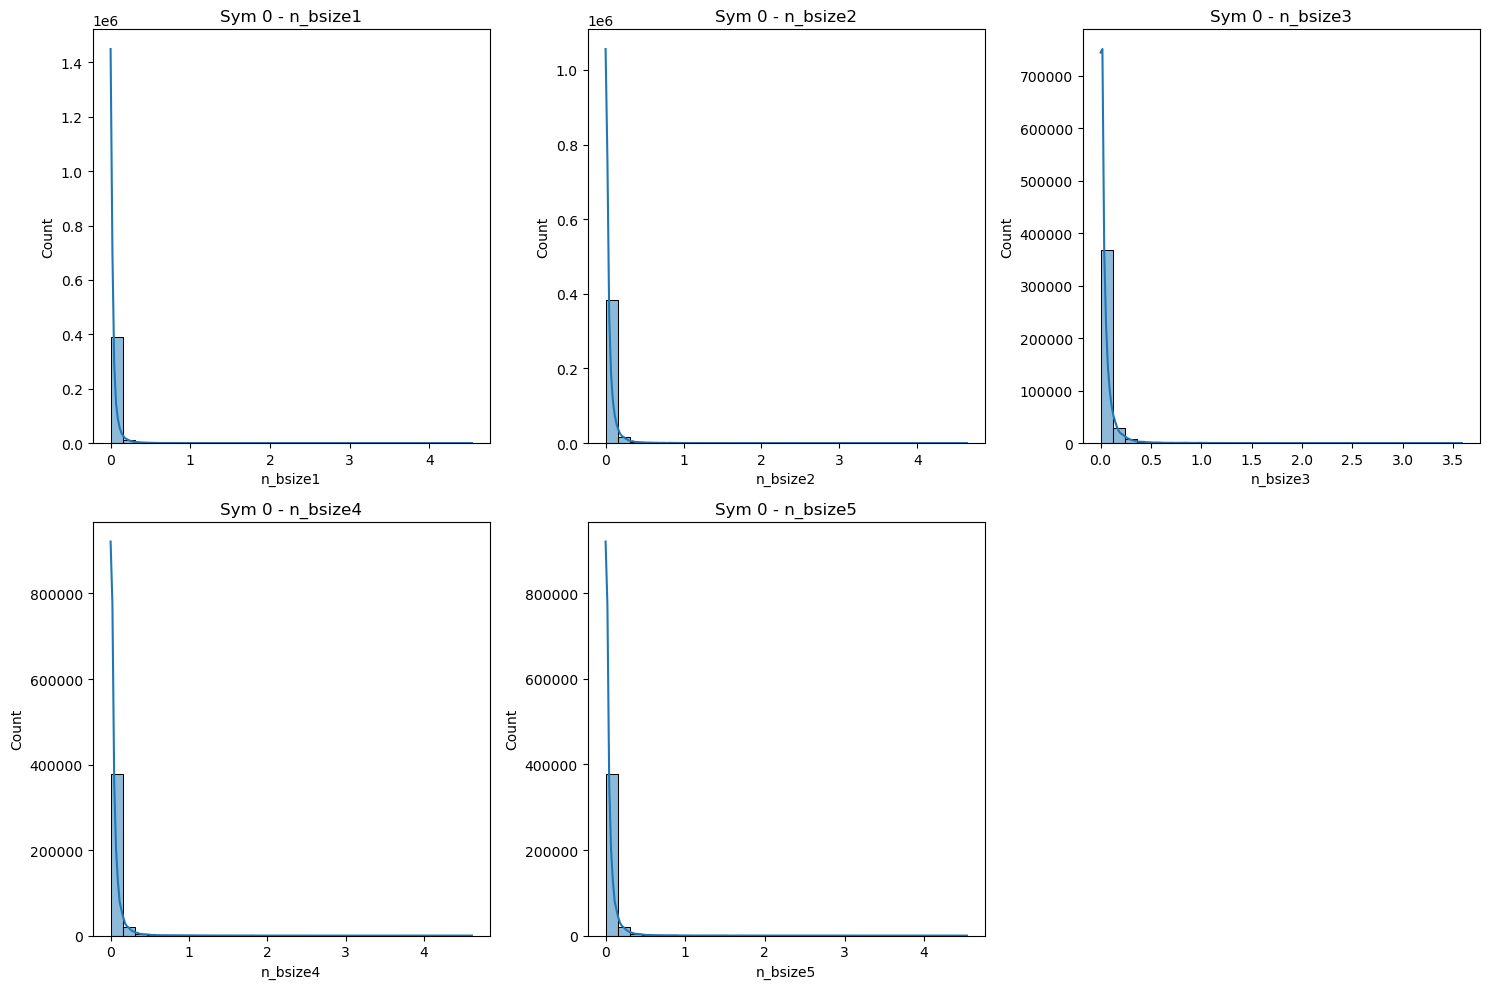

In [15]:
plot_hist(0, bsize_cols, normal_df)

In [17]:
# 确实极端右偏，取对数试一试
# 取对数
normal_df = normal_df.copy()
# 取对数
for col in bsize_cols:
    normal_df[f'log_{col}'] = np.log1p(normal_df[col])
# 检测右偏程度
log_bsize_cols = [f'log_{col}' for col in bsize_cols]
print(skew(normal_df[log_bsize_cols]))  # >2 表示严重右偏

[6.76658235 5.44738651 5.13229672 5.16708314 5.12856803]


In [18]:
# 分sym编号看一下
for sym in range(5):
    sym_df = normal_df[normal_df['sym'] == sym]
    print(f"Sym: {sym}")
    print("Skewness:", skew(sym_df[log_bsize_cols]))
    print()

Sym: 0
Skewness: [6.13659482 5.74597452 5.44213758 5.64863016 5.57310746]

Sym: 1
Skewness: [12.05057252 13.43408304 14.20451157 14.60085065 13.99731447]

Sym: 2
Skewness: [5.15201303 4.12982581 4.07785521 4.25719    4.34166787]

Sym: 3
Skewness: [5.82596003 4.37813023 4.17773257 4.24621119 4.08285712]

Sym: 4
Skewness: [5.47762189 5.17835566 4.95178047 4.89574558 5.02267818]



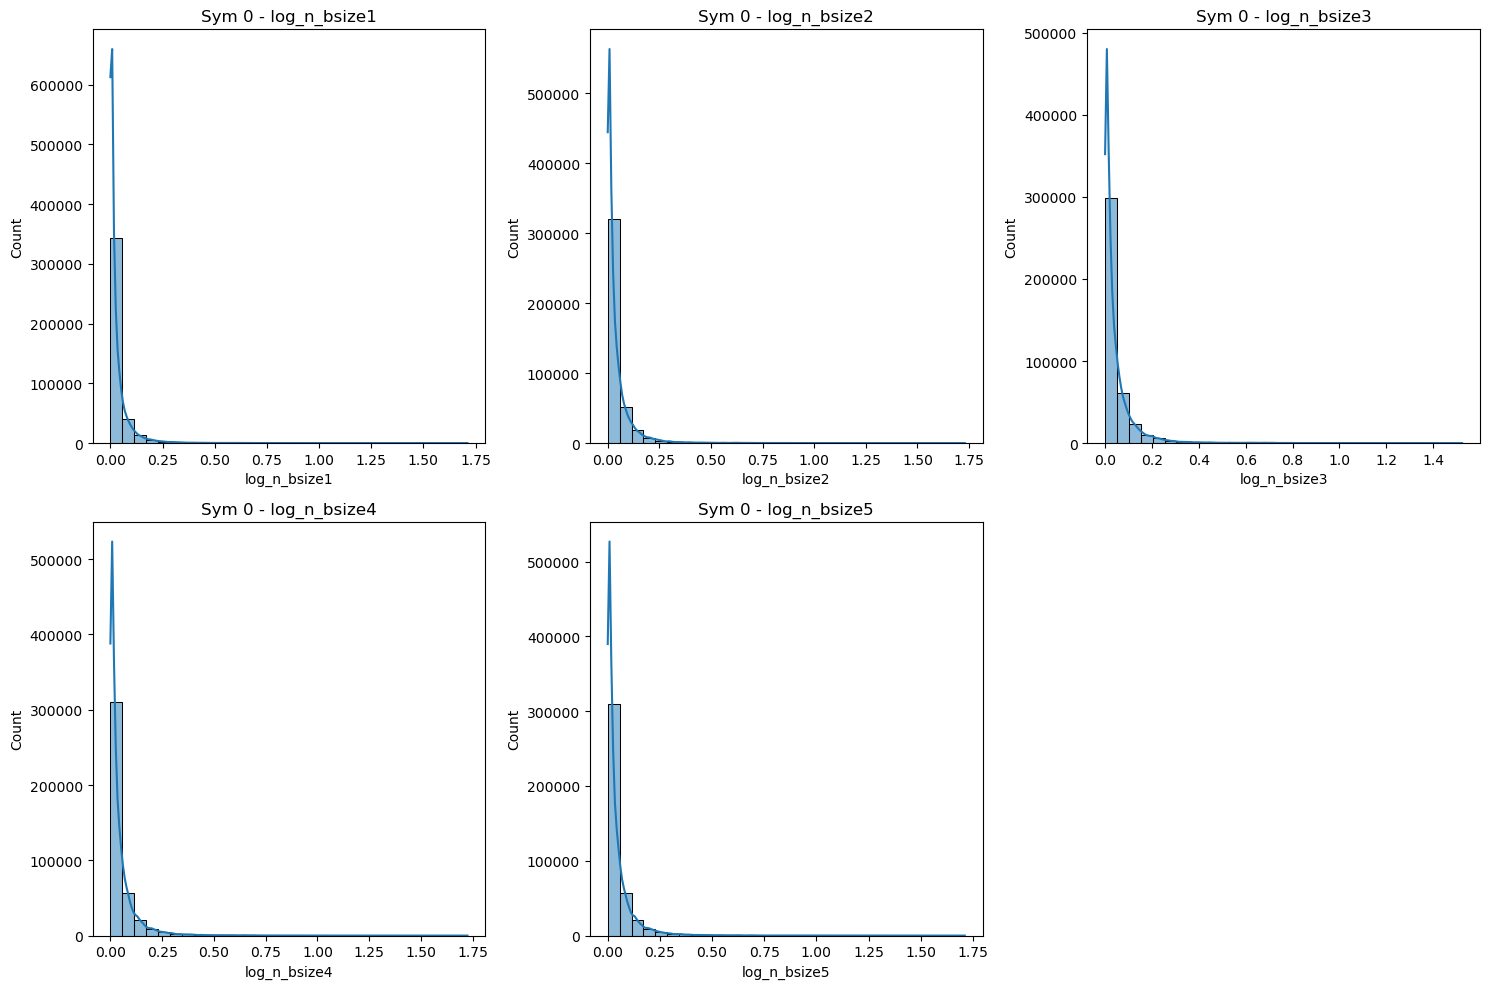

In [19]:
plot_hist(0, log_bsize_cols, normal_df)

In [22]:
# 还是极端右偏，说明取对数不管用
# 试试Box-Cox变换
from scipy.stats import boxcox
def boxcox_transformation(data):
    transformed_data, lambda_param = boxcox(data)
    return transformed_data



In [23]:
boxcox_df = normal_df.copy()
# 进行Box-Cox变换
for col in bsize_cols:
    boxcox_df[f'boxcox_{col}'] = boxcox_transformation(boxcox_df[col])
boxcox_bsize_cols = [f'boxcox_{col}' for col in bsize_cols]
# 检测右偏程度
print(skew(boxcox_df[boxcox_bsize_cols]))  # >2 表示严重右偏

[-0.00356312 -0.00853031 -0.00884743 -0.00783824 -0.00751572]


In [27]:
# 分sym编号看一下
for sym in range(5):
    sym_df = boxcox_df[boxcox_df['sym'] == sym]
    print(f"Sym: {sym}")
    print("Skewness:", skew(sym_df[boxcox_bsize_cols]))
    print()

Sym: 0
Skewness: [-0.12461439 -0.14579578 -0.15810401 -0.16222128 -0.16870463]

Sym: 1
Skewness: [0.73169575 0.82087374 0.76805065 0.74371888 0.74557159]

Sym: 2
Skewness: [-0.47816732 -0.54454772 -0.36516063 -0.26754992 -0.23374354]

Sym: 3
Skewness: [-0.27144626 -0.35880187 -0.2990095  -0.26295231 -0.23192057]

Sym: 4
Skewness: [0.24556663 0.23371576 0.2332866  0.23034921 0.2254948 ]



In [25]:
boxcox_df[boxcox_bsize_cols].describe()

,boxcox_n_bsize1,boxcox_n_bsize2,boxcox_n_bsize3,boxcox_n_bsize4,boxcox_n_bsize5
count,2.029588e+06,2.029588e+06,2.029588e+06,2.029588e+06,2.029588e+06
mean,-3.988031e+00,-3.491632e+00,-3.380690e+00,-3.391793e+00,-3.418114e+00
std,1.513220e+00,1.406991e+00,1.383611e+00,1.414089e+00,1.436510e+00
min,-1.180799e+01,-9.182038e+00,-8.989531e+00,-9.227986e+00,-9.502235e+00
25%,-5.081432e+00,-4.522467e+00,-4.360634e+00,-4.411846e+00,-4.446853e+00
50%,-3.947513e+00,-3.431693e+00,-3.315711e+00,-3.335757e+00,-3.357191e+00
75%,-2.904878e+00,-2.488318e+00,-2.401877e+00,-2.392215e+00,-2.399725e+00
max,2.275491e+00,2.427969e+00,2.271021e+00,2.311421e+00,2.892182e+00


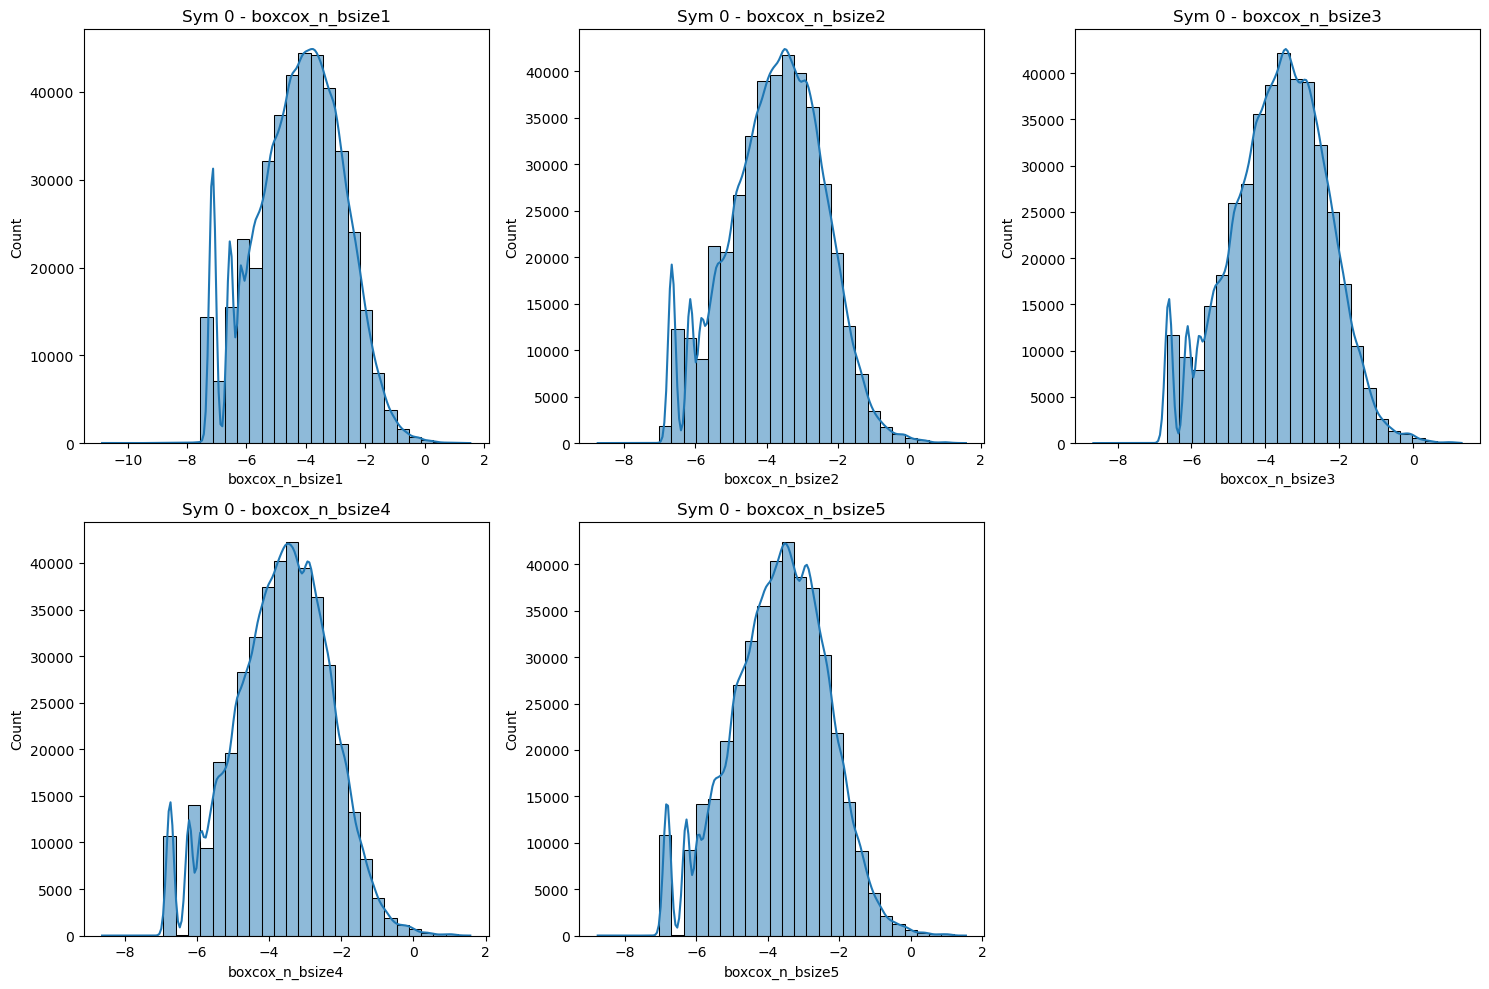

In [26]:
plot_hist(0, boxcox_bsize_cols, boxcox_df)

In [ ]:
# 画Q-Q图，看看是否近似正态分布
# 几十万几百万的大样本不适合做假设检验
# 微小扰动对结果非常明显
from scipy.stats import probplot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 行 3 列的子图布局

for i, col in enumerate(boxcox_bsize_cols):
    subset = boxcox_df[col]
    probplot(subset['amount'], dist="norm", plot=axes[i]) 
    axes[i].set_title(f'Q-Q Plot for sym={sym}') 
# 最后一个还是全体的
probplot(df['amount'], dist="norm", plot=axes[5]) 
axes[5].set_title(f'Q-Q Plot for sym={-1}')  

plt.tight_layout()  # 调整子图间距
plt.show()

In [30]:
from scipy.stats import probplot

In [33]:
def plot_qq(sym, cols, df):
    # 设置画布大小
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()  # 将 axes 转化为一维数组，便于索引

    # 筛选出指定 sym 的数据
    sym_df = df[df['sym'] == sym]

    # 画6个子图
    for i, col in enumerate(cols):
        probplot(sym_df[col], dist="norm", plot=axes[i])  # 使用 axes[i] 来画每个 Q-Q 图
        axes[i].set_title(f'Q-Q Plot for {sym}-{col}')  # 为每个子图设置标题

    # 调整布局
    plt.tight_layout()
    plt.show()

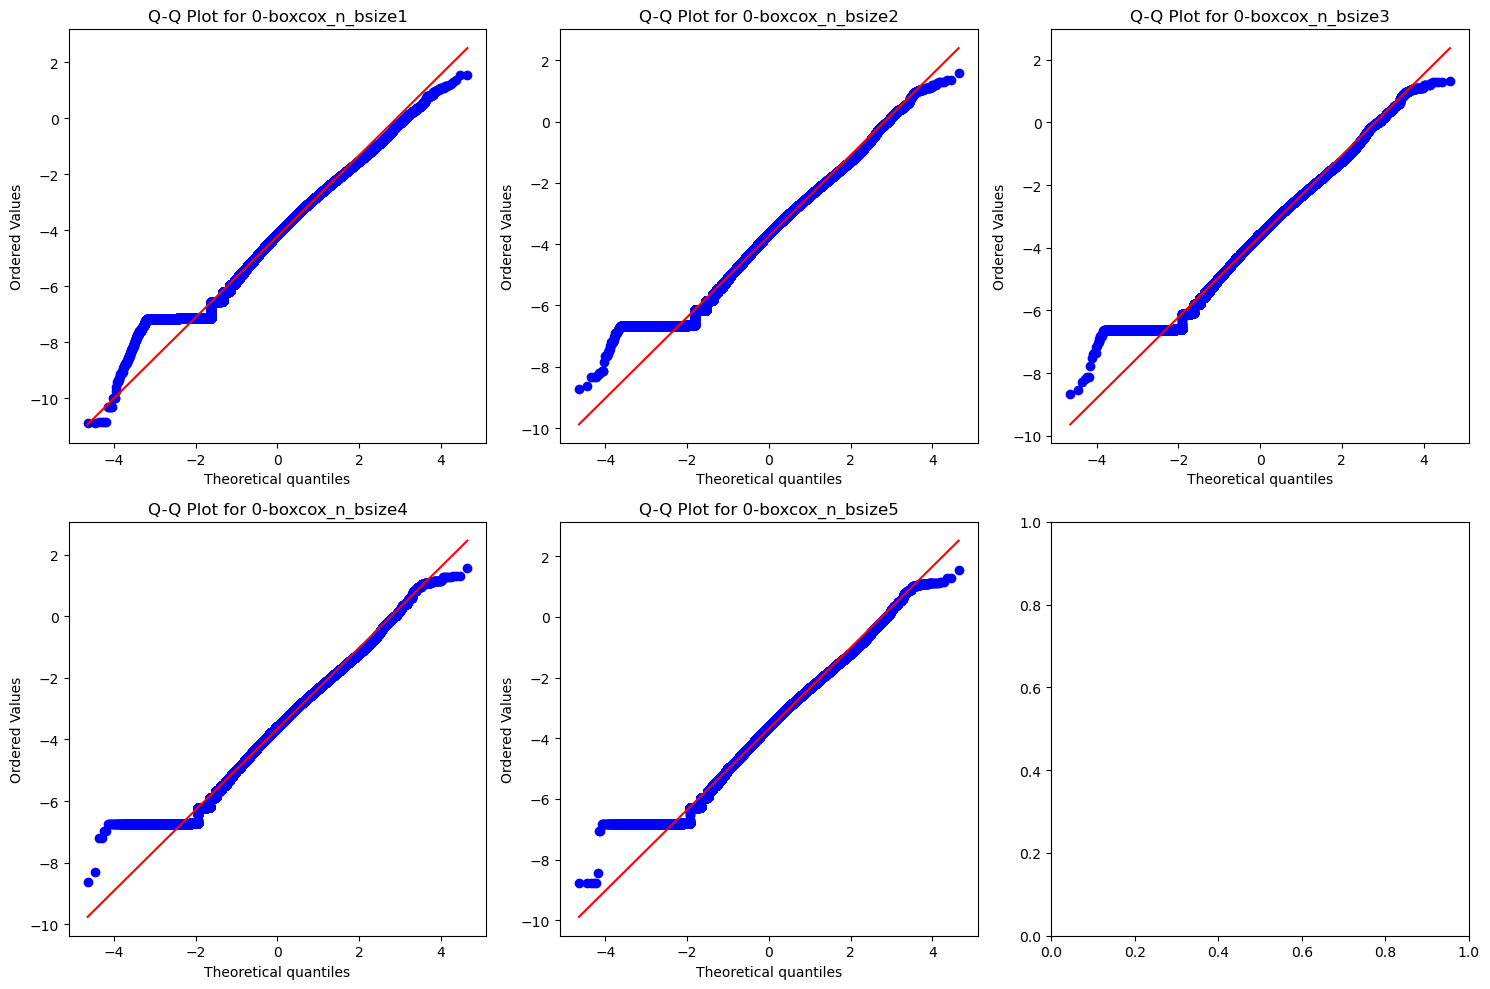

In [40]:
plot_qq(0, boxcox_bsize_cols, boxcox_df)
# 画Q-Q图，看看是否近似正态分布